But du Notebook

Vérifier la qualité des données du projet. Réaliser un feature engineering

# 1. Initialisation

## 1.1 Package 

In [1]:
import os
import copy

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno

In [2]:
# Construction des dataset
from sklearn.model_selection import train_test_split

In [3]:
# Pipeline

##from sklearn.pipeline import Pipeline

# Pour utiliser SMOTE dans un pipeline il faut prendre l'outil pipe de sk imbalance learn
from imblearn.pipeline import Pipeline

from sklearn.model_selection import GridSearchCV # Recherche d'hyperparametre
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder, OrdinalEncoder, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import FunctionTransformer
from sklearn.compose import ColumnTransformer

In [4]:
# Définition d'une metric
from sklearn.metrics import confusion_matrix, make_scorer

In [5]:
# Réduction de dimension
from sklearn.decomposition import PCA

In [6]:
# Synthetic Minority Oversampling Technique SMOTE
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler

In [7]:
# Modeles
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import HistGradientBoostingClassifier

## 1.2 Fonction

# 2. Données

## 2.1 Importation 

Chemins des dossiers

In [8]:
input_directory = r"./data/transformed/"
out_directory = r"./data/modeles/"

Noms des fichiers

In [9]:
os.listdir(input_directory)

['train_data_V0', 'train_data_V1']

In [10]:
raw = pd.read_csv(os.path.join(input_directory, "train_data_V1"))
print(raw.shape)
raw.head()

(356251, 778)


,SK_ID_CURR,TARGET,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,...,CC_NAME_CONTRACT_STATUS_Sent proposal_MAX,CC_NAME_CONTRACT_STATUS_Sent proposal_MEAN,CC_NAME_CONTRACT_STATUS_Sent proposal_SUM,CC_NAME_CONTRACT_STATUS_Sent proposal_VAR,CC_NAME_CONTRACT_STATUS_Signed_MIN,CC_NAME_CONTRACT_STATUS_Signed_MAX,CC_NAME_CONTRACT_STATUS_Signed_MEAN,CC_NAME_CONTRACT_STATUS_Signed_SUM,CC_NAME_CONTRACT_STATUS_Signed_VAR,CC_COUNT
0,100002,1.0,0,0,0,0,202500.0,406597.5,24700.5,351000.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,100003,0.0,1,0,1,0,270000.0,1293502.5,35698.5,1129500.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,100004,0.0,0,1,0,0,67500.0,135000.0,6750.0,135000.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,100006,0.0,1,0,0,0,135000.0,312682.5,29686.5,297000.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,6.0
4,100007,0.0,0,0,0,0,121500.0,513000.0,21865.5,513000.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [11]:
data = raw.loc[~raw["TARGET"].isna(), :]
print(data.shape)
data.head()

(307507, 778)


,SK_ID_CURR,TARGET,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,...,CC_NAME_CONTRACT_STATUS_Sent proposal_MAX,CC_NAME_CONTRACT_STATUS_Sent proposal_MEAN,CC_NAME_CONTRACT_STATUS_Sent proposal_SUM,CC_NAME_CONTRACT_STATUS_Sent proposal_VAR,CC_NAME_CONTRACT_STATUS_Signed_MIN,CC_NAME_CONTRACT_STATUS_Signed_MAX,CC_NAME_CONTRACT_STATUS_Signed_MEAN,CC_NAME_CONTRACT_STATUS_Signed_SUM,CC_NAME_CONTRACT_STATUS_Signed_VAR,CC_COUNT
0,100002,1.0,0,0,0,0,202500.0,406597.5,24700.5,351000.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,100003,0.0,1,0,1,0,270000.0,1293502.5,35698.5,1129500.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,100004,0.0,0,1,0,0,67500.0,135000.0,6750.0,135000.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,100006,0.0,1,0,0,0,135000.0,312682.5,29686.5,297000.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,6.0
4,100007,0.0,0,0,0,0,121500.0,513000.0,21865.5,513000.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [12]:
data.TARGET.unique()

array([1., 0.])

In [13]:
data.loc[:, data.columns[2:]]

,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,REGION_POPULATION_RELATIVE,DAYS_BIRTH,...,CC_NAME_CONTRACT_STATUS_Sent proposal_MAX,CC_NAME_CONTRACT_STATUS_Sent proposal_MEAN,CC_NAME_CONTRACT_STATUS_Sent proposal_SUM,CC_NAME_CONTRACT_STATUS_Sent proposal_VAR,CC_NAME_CONTRACT_STATUS_Signed_MIN,CC_NAME_CONTRACT_STATUS_Signed_MAX,CC_NAME_CONTRACT_STATUS_Signed_MEAN,CC_NAME_CONTRACT_STATUS_Signed_SUM,CC_NAME_CONTRACT_STATUS_Signed_VAR,CC_COUNT
0,0,0,0,0,202500.0,406597.5,24700.5,351000.0,0.018801,-9461,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1,0,1,0,270000.0,1293502.5,35698.5,1129500.0,0.003541,-16765,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,0,1,0,0,67500.0,135000.0,6750.0,135000.0,0.010032,-19046,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,1,0,0,0,135000.0,312682.5,29686.5,297000.0,0.008019,-19005,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,6.0
4,0,0,0,0,121500.0,513000.0,21865.5,513000.0,0.028663,-19932,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
307502,0,0,1,0,157500.0,254700.0,27558.0,225000.0,0.032561,-9327,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
307503,1,0,0,0,72000.0,269550.0,12001.5,225000.0,0.025164,-20775,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
307504,1,0,0,0,153000.0,677664.0,29979.0,585000.0,0.005002,-14966,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
307505,1,0,0,0,171000.0,370107.0,20205.0,319500.0,0.005313,-11961,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 2.2 Qualité de la données

- Erreur, présence de valeurs infinit dans le dataset

In [14]:
# Verifier la présence d'infinit
data.isin([np.inf, -np.inf]).any().value_counts()

False    771
True       7
Name: count, dtype: int64

In [15]:
# Identifier les colonnes

In [16]:
inf_column = data.columns[data.isin([np.inf, -np.inf]).any() ]

In [17]:
# Identifier les lignes
drop_index = np.array([])
for column in inf_column :
    index = data.loc[data[column].isin([np.inf, -np.inf]), column].index
    print(index)
    
    index = np.array(index)
    drop_index = np.append(drop_index, index)

drop_index = np.unique(drop_index)

Index([201082], dtype='int64')
Index([201082], dtype='int64')
Index([201082], dtype='int64')
Index([201082], dtype='int64')
Index([  5687,  60475,  79075,  89015,  98506, 126765, 128788, 140423, 152084,
       167133, 199099, 236160, 238377, 272825, 277958, 287296, 292848, 305369],
      dtype='int64')
Index([  5687,  60475,  79075,  89015,  98506, 126765, 128788, 140423, 152084,
       167133, 199099, 236160, 238377, 272825, 277958, 287296, 292848, 305369],
      dtype='int64')
Index([  5687,  60475,  79075,  89015,  98506, 126765, 128788, 140423, 152084,
       167133, 199099, 236160, 238377, 272825, 277958, 287296, 292848, 305369],
      dtype='int64')


In [18]:
print(f"{len(drop_index)} lignes contiennent des valeurs inf")

19 lignes contiennent des valeurs inf


On vire toutes les lignes qui contiennent ces valeurs. Pourrai aussi les rendre null

In [19]:
data = data.drop(drop_index)
# Verifier la présence d'infinit
data.isin([np.inf, -np.inf]).any().value_counts()

False    778
Name: count, dtype: int64

In [20]:
del drop_index

- Type de données

In [21]:
data.info(verbose=True, show_counts=True)

<class 'pandas.core.frame.DataFrame'>
Index: 307488 entries, 0 to 307506
Data columns (total 778 columns):
 #    Column                                                                 Non-Null Count   Dtype  
---   ------                                                                 --------------   -----  
 0    SK_ID_CURR                                                             307488 non-null  int64  
 1    TARGET                                                                 307488 non-null  float64
 2    CODE_GENDER                                                            307488 non-null  int64  
 3    FLAG_OWN_CAR                                                           307488 non-null  int64  
 4    FLAG_OWN_REALTY                                                        307488 non-null  int64  
 5    CNT_CHILDREN                                                           307488 non-null  int64  
 6    AMT_INCOME_TOTAL                                                       

In [22]:
print("Datastet V0")
print(data.select_dtypes("object").columns)

Datastet V0
Index([], dtype='object')


V0 : plusieur colonnes sont de type object ce qui risque de causer des problème pour la suite  
V1 : Pas de colonne avec un type objet

# 3. Test du pipeline

## 3.1 Définition du pipeline

Le pipeline doit réaliser plusieurs fonction :
- Encodage, réaliser lors du feature engineering notebook, data_preprocess
- Imputation, remplire les NaN du dataframe
- SMOTE, gestion du déséquilibre de classe : [Guide d'utilisation](https://machinelearningmastery.com/smote-oversampling-for-imbalanced-classification/)
- Classification, model en lui même classe les clients en deux catégorie. Vas rembourser le crédits, ne vas pas rembourser le crédit
- Optimisation du seuil de décision, le modèle calcul une probabiliter qui doit être transformer en classifieur avec un seuil qui peut être optimisé

In [23]:
y.value_counts()
# Détermine the under sampling ratio

NameError: name 'y' is not defined

In [24]:
'''
Pas besoin d'un transformer dans le pipeline l'encodage est réaliser lors du feature engineering

transformer = ColumnTransformer([ # Encodage des variables type object 
              ("Ordi_encoder", OrdinalEncoder(), tow_class_columns),
              ("one-hot_encoder", OneHotEncoder(sparse_output=False), more_class_columns)
                ])
'''

pipe = Pipeline([
              #("transformer", transformer),
              ("imputer", SimpleImputer(strategy = "median", missing_values = float("nan"))),
              ("under_SMOTE", RandomUnderSampler(sampling_strategy="auto")),
              ("over_SMOTE", SMOTE(random_state=42)),
              ("pca", PCA()),
              ("Scaler", MinMaxScaler()),
              ("Classifier", RandomForestClassifier()), # Place holder qui seras remplacer lors du grid search
              #("Threshold_tuner", )
                ])

RandomUnderSampler [lien vers la fiche fonction](https://imbalanced-learn.org/stable/references/generated/imblearn.under_sampling.RandomUnderSampler.html)

In [25]:
pipe

,steps,"[('imputer', ...), ('under_SMOTE', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,"missing_values missing_values: int, float, str, np.nan, None or pandas.NA, default=np.nanThe placeholder for the missing values. All occurrences of`missing_values` will be imputed. For pandas' dataframes withnullable integer dtypes with missing values, `missing_values`can be set to either `np.nan` or `pd.NA`.",nan
,"strategy strategy: str or Callable, default='mean'The imputation strategy.- If ""mean"", then replace missing values using the mean along each column. Can only be used with numeric data.- If ""median"", then replace missing values using the median along each column. Can only be used with numeric data.- If ""most_frequent"", then replace missing using the most frequent value along each column. Can be used with strings or numeric data. If there is more than one such value, only the smallest is returned.- If ""constant"", then replace missing values with fill_value. Can be used with strings or numeric data.- If an instance of Callable, then replace missing values using the scalar statistic returned by running the callable over a dense 1d array containing non-missing values of each column... versionadded:: 0.20 strategy=""constant"" for fixed value imputation... versionadded:: 1.5 strategy=callable for custom value imputation.",'median'
,"fill_value fill_value: str or numerical value, default=NoneWhen strategy == ""constant"", `fill_value` is used to replace alloccurrences of missing_values. For string or object data types,`fill_value` must be a string.If `None`, `fill_value` will be 0 when imputing numericaldata and ""missing_value"" for strings or object data types.",None
,"copy copy: bool, default=TrueIf True, a copy of X will be created. If False, imputation willbe done in-place whenever possible. Note that, in the following cases,a new copy will always be made, even if `copy=False`:- If `X` is not an array of floating values;- If `X` is encoded as a CSR matrix;- If `add_indicator=True`.",True
,"add_indicator add_indicator: bool, default=FalseIf True, a :class:`MissingIndicator` transform will stack onto outputof the imputer's transform. This allows a predictive estimatorto account for missingness despite imputation. If a feature has nomissing values at fit/train time, the feature won't appear onthe missing indicator even if there are missing values attransform/test time.",False
,"keep_empty_features keep_empty_features: bool, default=FalseIf True, features that consist exclusively of missing values when`fit` is called are returned in results when `transform` is called.The imputed value is always `0` except when `strategy=""constant""`in which case `fill_value` will be used instead... versionadded:: 1.2",False
,sampling_strategy,'auto'


## 3.2 Définition de la metric

Refaire la métric pour ne pas mettre de trheshold à l'intérieur

In [53]:
def my_metric(y_true, y_pred):
    
    cm = confusion_matrix(y_true, y_pred)

    gain_matrix = np.array(
        [
            [0, -10],
            [-1, 0]
        ]
    )
    return np.sum(cm * gain_matrix)
    
my_scorer = make_scorer(my_metric, response_method="predict")

Définition du grid search

In [54]:
# Définir un grid search avec plusieurs modèles
param_grid = [
    {
        # ----- Linear Regression (no hyper‑params to tune) -----
        'pca__n_components' : [25],
        "Classifier": [LogisticRegression(C=10)],
    },
    {
        # ----- Random Forest -------------------------------------------------
        'pca__n_components' : [25],
        "Classifier": [RandomForestClassifier(random_state=42)],
        "Classifier__n_estimators": [100],
        "Classifier__max_depth": [None, 10],
        #"model__min_samples_split": [2, 5],
    },
    {
        # ----- Support‑Vector Regressor ---------------------------------------
        'pca__n_components' : [25],
        "Classifier": [HistGradientBoostingClassifier(random_state=42)],
        "Classifier__learning_rate": [0.1, 1],
        "Classifier__max_depth": [None, 10],
    },
]

In [55]:
# Définir la GridSearch avec le scorer
grid_search = GridSearchCV(pipe, param_grid, scoring=my_scorer, n_jobs=5, error_score='raise')

## 3.3 Test pipeline

In [56]:
pipe

,steps,"[('imputer', ...), ('under_SMOTE', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,"missing_values missing_values: int, float, str, np.nan, None or pandas.NA, default=np.nanThe placeholder for the missing values. All occurrences of`missing_values` will be imputed. For pandas' dataframes withnullable integer dtypes with missing values, `missing_values`can be set to either `np.nan` or `pd.NA`.",nan
,"strategy strategy: str or Callable, default='mean'The imputation strategy.- If ""mean"", then replace missing values using the mean along each column. Can only be used with numeric data.- If ""median"", then replace missing values using the median along each column. Can only be used with numeric data.- If ""most_frequent"", then replace missing using the most frequent value along each column. Can be used with strings or numeric data. If there is more than one such value, only the smallest is returned.- If ""constant"", then replace missing values with fill_value. Can be used with strings or numeric data.- If an instance of Callable, then replace missing values using the scalar statistic returned by running the callable over a dense 1d array containing non-missing values of each column... versionadded:: 0.20 strategy=""constant"" for fixed value imputation... versionadded:: 1.5 strategy=callable for custom value imputation.",'median'
,"fill_value fill_value: str or numerical value, default=NoneWhen strategy == ""constant"", `fill_value` is used to replace alloccurrences of missing_values. For string or object data types,`fill_value` must be a string.If `None`, `fill_value` will be 0 when imputing numericaldata and ""missing_value"" for strings or object data types.",None
,"copy copy: bool, default=TrueIf True, a copy of X will be created. If False, imputation willbe done in-place whenever possible. Note that, in the following cases,a new copy will always be made, even if `copy=False`:- If `X` is not an array of floating values;- If `X` is encoded as a CSR matrix;- If `add_indicator=True`.",True
,"add_indicator add_indicator: bool, default=FalseIf True, a :class:`MissingIndicator` transform will stack onto outputof the imputer's transform. This allows a predictive estimatorto account for missingness despite imputation. If a feature has nomissing values at fit/train time, the feature won't appear onthe missing indicator even if there are missing values attransform/test time.",False
,"keep_empty_features keep_empty_features: bool, default=FalseIf True, features that consist exclusively of missing values when`fit` is called are returned in results when `transform` is called.The imputed value is always `0` except when `strategy=""constant""`in which case `fill_value` will be used instead... versionadded:: 1.2",False
,sampling_strategy,'auto'


Entrainer le pipeline sur un semple du dataset

In [57]:
# Sampling
tmp = data.sample(10000, random_state=42)
X_tmp = tmp.loc[: , tmp.columns[2:]]
y_tmp = tmp["TARGET"]

In [58]:
# Effectuer la recherche
grid_search.fit(X_tmp, y_tmp)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...lassifier())])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","[{'Classifier': [LogisticRegression(C=10)], 'pca__n_components': [25]}, {'Classifier': [RandomForestC...ndom_state=42)], 'Classifier__max_depth': [None, 10], 'Classifier__n_estimators': [100], 'pca__n_components': [25]}, ...]"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",make_scorer(m...hod='predict')
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",5
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",None
,

In [59]:
print("Best estimator :", grid_search.best_estimator_)
print("Best CV score  :", -grid_search.best_score_)   # MSE (positive)
print("Chosen model   :", type(grid_search.best_estimator_.named_steps["Classifier"]).__name__)

Best estimator : Pipeline(steps=[('imputer', SimpleImputer(strategy='median')),
                ('under_SMOTE', RandomUnderSampler()),
                ('over_SMOTE', SMOTE(random_state=42)),
                ('pca', PCA(n_components=25)), ('Scaler', MinMaxScaler()),
                ('Classifier',
                 HistGradientBoostingClassifier(random_state=42))])
Best CV score  : 7704.6
Chosen model   : HistGradientBoostingClassifier


In [60]:
# Dummy V1, plusieurs modèle, seuil None
grid_search.best_score_

np.float64(-7704.6)

In [38]:
# Dummy VO, seuil 0.09
grid_search.best_score_

np.float64(-4338.0)

In [41]:
# Dummy VO, seuil 0.5
grid_search.best_score_

np.float64(-4338.0)

In [75]:
# ACP V1, seuil 0.5
grid_search.best_score_

np.float64(-148.4)

In [87]:
# ACP V1, seuil 0.5, RandomForestClassifier
grid_search.best_score_

np.float64(-148.4)

In [ ]:
# data V0Seuil 0.9 SMOTE
grid_search.best_score_

In [ ]:
# Seuil 0.9 SMOTE
grid_search.best_score_

In [ ]:
# Seuil de 0.9
grid_search.best_score_

In [ ]:
# Seuil de  0.8
grid_search.best_score_

In [ ]:
best_model = grid_search.best_estimator_

In [ ]:
best_model

In [ ]:
y_pred = best_model.predict_proba(X_tmp)
y_pred

In [ ]:
y_pred = y_pred[:,1]
y_pred

In [ ]:
y_pred = pd.Series(y_pred, name="y_pred")

In [ ]:
pred_df = pd.concat([y.reset_index(drop=True), y_pred], axis=1)

In [ ]:
pred_df.loc[:, "pred_label"] = (pred_df["y_pred"] >= threshold).astype(int)

# 4. Suivie des entrainement avec mlflow

In [69]:
# Mlflow
import pprint
import mlflow
# from mlflow.utils import fetch_logged_data

## 4.1 Définition de l'entrainement

Je vais entrainer plusieurs modèles avec ce notebook en changeant le pipeline définit en dessous et le dataset. Les résultats serons stocker dans la base de données de mlflow.

Plan d'expérience :  
- data : VO, impute : median, Scaler : min-max, model : LogistiqueRegression, treshold : 0.5) "dummy1"
- data : V1, impute : median, Scaler : min-max, model : LogistiqueRegression, treshold : 0.5) "dummy2"
- data : V1, impute : median, ACP=True, Scaler : min-max, model : LogistiqueRegression, treshold : 0.5
- data : V1, impute : median, ACP=True, Scaler : min-max, model : LogistiqueRegression, RandomForestClassifier, HistGradientBoostedTree, treshold : 0.09
- data : V1, impute : median, SMOTE(under over), ACP=True, Scaler : min-max, model : LogistiqueRegression, RandomForestClassifier, HistGradientBoostedTree, treshold : 0.09
- data : V1, impute : median, SMOTE(under over), ACP=True, Scaler : min-max, model : LogistiqueRegression, RandomForestClassifier, HistGradientBoostedTree, treshold : 0.5
- train/test: True, data : V1, impute : median, SMOTE(under over), ACP=True, Scaler : min-max, model : LogistiqueRegression, RandomForestClassifier, HistGradientBoostedTree, threshold : 0.5
- train/test: True, threshold= False, data : V1, impute : median, SMOTE(under over), ACP=True, Scaler : min-max, model : LogistiqueRegression, RandomForestClassifier, HistGradientBoostedTree, threshold=False
- train/test: True, threshold= False, data : V1, impute : median, SMOTE(under over), ACP=False, Scaler : min-max, model : LogistiqueRegression, RandomForestClassifier, HistGradientBoostedTree, threshold=False

In [104]:
'''
Pas besoin d'un transformer dans le pipeline l'encodage est réaliser lors du feature engineering

transformer = ColumnTransformer([ # Encodage des variables type object 
              ("Ordi_encoder", OrdinalEncoder(), tow_class_columns),
              ("one-hot_encoder", OneHotEncoder(sparse_output=False), more_class_columns)
                ])
'''

pipe = Pipeline([
              #("transformer", transformer),
              ("imputer", SimpleImputer(strategy = "median", missing_values = float("nan"))),
              ("under_SMOTE", RandomUnderSampler(sampling_strategy="auto")),
              ("over_SMOTE", SMOTE(random_state=42)),
              #("pca", PCA()),
              ("Scaler", MinMaxScaler()),
              ("Classifier", RandomForestClassifier()), # Place holder qui seras remplacer lors du grid search
              #("Threshold_tuner", )
                ])

RandomUnderSampler [lien vers la fiche fonction](https://imbalanced-learn.org/stable/references/generated/imblearn.under_sampling.RandomUnderSampler.html)

In [105]:
pipe

,steps,"[('imputer', ...), ('under_SMOTE', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,"missing_values missing_values: int, float, str, np.nan, None or pandas.NA, default=np.nanThe placeholder for the missing values. All occurrences of`missing_values` will be imputed. For pandas' dataframes withnullable integer dtypes with missing values, `missing_values`can be set to either `np.nan` or `pd.NA`.",nan
,"strategy strategy: str or Callable, default='mean'The imputation strategy.- If ""mean"", then replace missing values using the mean along each column. Can only be used with numeric data.- If ""median"", then replace missing values using the median along each column. Can only be used with numeric data.- If ""most_frequent"", then replace missing using the most frequent value along each column. Can be used with strings or numeric data. If there is more than one such value, only the smallest is returned.- If ""constant"", then replace missing values with fill_value. Can be used with strings or numeric data.- If an instance of Callable, then replace missing values using the scalar statistic returned by running the callable over a dense 1d array containing non-missing values of each column... versionadded:: 0.20 strategy=""constant"" for fixed value imputation... versionadded:: 1.5 strategy=callable for custom value imputation.",'median'
,"fill_value fill_value: str or numerical value, default=NoneWhen strategy == ""constant"", `fill_value` is used to replace alloccurrences of missing_values. For string or object data types,`fill_value` must be a string.If `None`, `fill_value` will be 0 when imputing numericaldata and ""missing_value"" for strings or object data types.",None
,"copy copy: bool, default=TrueIf True, a copy of X will be created. If False, imputation willbe done in-place whenever possible. Note that, in the following cases,a new copy will always be made, even if `copy=False`:- If `X` is not an array of floating values;- If `X` is encoded as a CSR matrix;- If `add_indicator=True`.",True
,"add_indicator add_indicator: bool, default=FalseIf True, a :class:`MissingIndicator` transform will stack onto outputof the imputer's transform. This allows a predictive estimatorto account for missingness despite imputation. If a feature has nomissing values at fit/train time, the feature won't appear onthe missing indicator even if there are missing values attransform/test time.",False
,"keep_empty_features keep_empty_features: bool, default=FalseIf True, features that consist exclusively of missing values when`fit` is called are returned in results when `transform` is called.The imputed value is always `0` except when `strategy=""constant""`in which case `fill_value` will be used instead... versionadded:: 1.2",False
,sampling_strategy,'auto'


Définition de la metric

In [106]:
# Metric plus simple, sans seuil 
def my_metric(y_true, y_pred):
    
    cm = confusion_matrix(y_true, y_pred)

    gain_matrix = np.array(
        [
            [0, -10],
            [-1, 0]
        ]
    )
    return np.sum(cm * gain_matrix)
    
my_scorer = make_scorer(my_metric, response_method="predict")

Définition du grid search

In [111]:
# Définir un grid search avec plusieurs modèles
param_grid = [
    {
        # ----- Linear Regression (no hyper‑params to tune) -----
        #'pca__n_components' : [25],
        "Classifier": [LogisticRegression(C=10)],
    },
    {
        # ----- Random Forest -------------------------------------------------
        #'pca__n_components' : [25],
        "Classifier": [RandomForestClassifier(random_state=42)],
        "Classifier__n_estimators": [100],
        "Classifier__max_depth": [10],
        #"model__min_samples_split": [2, 5],
    },
    {
        # ----- Support‑Vector Regressor ---------------------------------------
        #'pca__n_components' : [25],
        "Classifier": [HistGradientBoostingClassifier(random_state=42)],
        "Classifier__learning_rate": [0.1],
        "Classifier__max_depth": [10],
    },
]

In [112]:
# Définir la GridSearch avec le scorer
grid_search = GridSearchCV(pipe, param_grid, scoring=my_scorer, n_jobs=5, error_score='raise')

## 4.2 Lancement du suivie

[adresse local du serveur de suivie](http://127.0.0.1:5000)

In [113]:
# Enclencher le suivie
mlflow.set_tracking_uri("sqlite:///data/mlflow.db")
mlflow.sklearn.autolog()
mlflow.set_experiment("Projet 7 Openclassrooms : Implementez un model de scoring")

<Experiment: artifact_location=('file:C:/Users/SUZON/OneDrive - CNR/Documents/Jupyter/Openclassrooms/Projets '
 'Openclassrooms/Projet-7-Implementez-un-modele-de-scoring/mlruns/4'), creation_time=1770373572030, experiment_id='4', last_update_time=1770373572030, lifecycle_stage='active', name='Projet 7 Openclassrooms : Implementez un model de scoring', tags={'mlflow.experimentKind': 'custom_model_development'}>

## 4.3 Lancement de la run

Rappel du pipeline définit

In [114]:
pipe

,steps,"[('imputer', ...), ('under_SMOTE', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,"missing_values missing_values: int, float, str, np.nan, None or pandas.NA, default=np.nanThe placeholder for the missing values. All occurrences of`missing_values` will be imputed. For pandas' dataframes withnullable integer dtypes with missing values, `missing_values`can be set to either `np.nan` or `pd.NA`.",nan
,"strategy strategy: str or Callable, default='mean'The imputation strategy.- If ""mean"", then replace missing values using the mean along each column. Can only be used with numeric data.- If ""median"", then replace missing values using the median along each column. Can only be used with numeric data.- If ""most_frequent"", then replace missing using the most frequent value along each column. Can be used with strings or numeric data. If there is more than one such value, only the smallest is returned.- If ""constant"", then replace missing values with fill_value. Can be used with strings or numeric data.- If an instance of Callable, then replace missing values using the scalar statistic returned by running the callable over a dense 1d array containing non-missing values of each column... versionadded:: 0.20 strategy=""constant"" for fixed value imputation... versionadded:: 1.5 strategy=callable for custom value imputation.",'median'
,"fill_value fill_value: str or numerical value, default=NoneWhen strategy == ""constant"", `fill_value` is used to replace alloccurrences of missing_values. For string or object data types,`fill_value` must be a string.If `None`, `fill_value` will be 0 when imputing numericaldata and ""missing_value"" for strings or object data types.",None
,"copy copy: bool, default=TrueIf True, a copy of X will be created. If False, imputation willbe done in-place whenever possible. Note that, in the following cases,a new copy will always be made, even if `copy=False`:- If `X` is not an array of floating values;- If `X` is encoded as a CSR matrix;- If `add_indicator=True`.",True
,"add_indicator add_indicator: bool, default=FalseIf True, a :class:`MissingIndicator` transform will stack onto outputof the imputer's transform. This allows a predictive estimatorto account for missingness despite imputation. If a feature has nomissing values at fit/train time, the feature won't appear onthe missing indicator even if there are missing values attransform/test time.",False
,"keep_empty_features keep_empty_features: bool, default=FalseIf True, features that consist exclusively of missing values when`fit` is called are returned in results when `transform` is called.The imputed value is always `0` except when `strategy=""constant""`in which case `fill_value` will be used instead... versionadded:: 1.2",False
,sampling_strategy,'auto'


Entrainement

In [115]:
with mlflow.start_run(run_name="train/test: True, threshold= False, data : V1, impute : median, SMOTE(under over), ACP=False, Scaler : min-max, model : LogistiqueRegression, RandomForestClassifier, HistGradientBoostedTree, threshold=False"):
    
    # Construire un train test split
    X_train, X_test, y_train, y_test = train_test_split(
                                                        data.loc[:, data.columns[2:]], data["TARGET"],
                                                        test_size=0.20,
                                                        random_state=42,
                                                        )
    # Vérifier que les deux set de données produit contiennent bien la calsse rare
    print(f"Nombre d'individue dans le split train : {y_train.value_counts(normalize=True)}")
    print(f"Nombre d'individue dans le split train : {y_test.value_counts(normalize=True)}")
    
    # Recherche d'hyper paramètre et entrainement
    grid_search.fit(X_train, y_train)

    # Score sur le set de test
    grid_search.score(X_test, y_test)

Nombre d'individue dans le split train : TARGET
0.0    0.919172
1.0    0.080828
Name: proportion, dtype: float64
Nombre d'individue dans le split train : TARGET
0.0    0.919672
1.0    0.080328
Name: proportion, dtype: float64


2026/02/13 13:21:15 WARNING mlflow.utils.autologging_utils: MLflow autologging encountered a warning: "D:\Users\SUZON\AppData\Local\anaconda3\envs\ml_flow_python_3_13_7\Lib\site-packages\mlflow\types\utils.py:452: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details."
2026/02/13 13:24:47 WARNING mlflow.utils.autologging_utils: MLflow autologging encountered a warning: "D:\Users\SUZON

In [117]:
# Score sur le set de test
grid_search.score(X_test, y_test)

np.int64(-167866)

In [116]:
print("Best estimator :", grid_search.best_estimator_)
print("Best CV score  :", -grid_search.best_score_)   # MSE (positive)
print("Chosen model   :", type(grid_search.best_estimator_.named_steps["Classifier"]).__name__)

Best estimator : Pipeline(steps=[('imputer', SimpleImputer(strategy='median')),
                ('under_SMOTE', RandomUnderSampler()),
                ('over_SMOTE', SMOTE(random_state=42)),
                ('Scaler', MinMaxScaler()),
                ('Classifier',
                 HistGradientBoostingClassifier(max_depth=10,
                                                random_state=42))])
Best CV score  : 134060.6
Chosen model   : HistGradientBoostingClassifier


## Optimisation du seuil de décision

In [118]:
model = grid_search.best_estimator_

In [119]:
pos_label = 0
neg_label = 1

def fpr_score(y, y_pred, neg_label, pos_label):
    cm = confusion_matrix(y, y_pred, labels=[neg_label, pos_label])
    tn, fp, _, _ = cm.ravel()
    tnr = tn / (tn + fp)
    return 1 - tnr

from sklearn.metrics import make_scorer, precision_score, recall_score

tpr_score = recall_score  # TPR and recall are the same metric

scoring = {
    "precision": make_scorer(precision_score, pos_label=pos_label),
    "recall": make_scorer(recall_score, pos_label=pos_label),
    "fpr": make_scorer(fpr_score, neg_label=neg_label, pos_label=pos_label),
    "tpr": make_scorer(tpr_score, pos_label=pos_label),
}

Graphique d'évaluation du best modèle

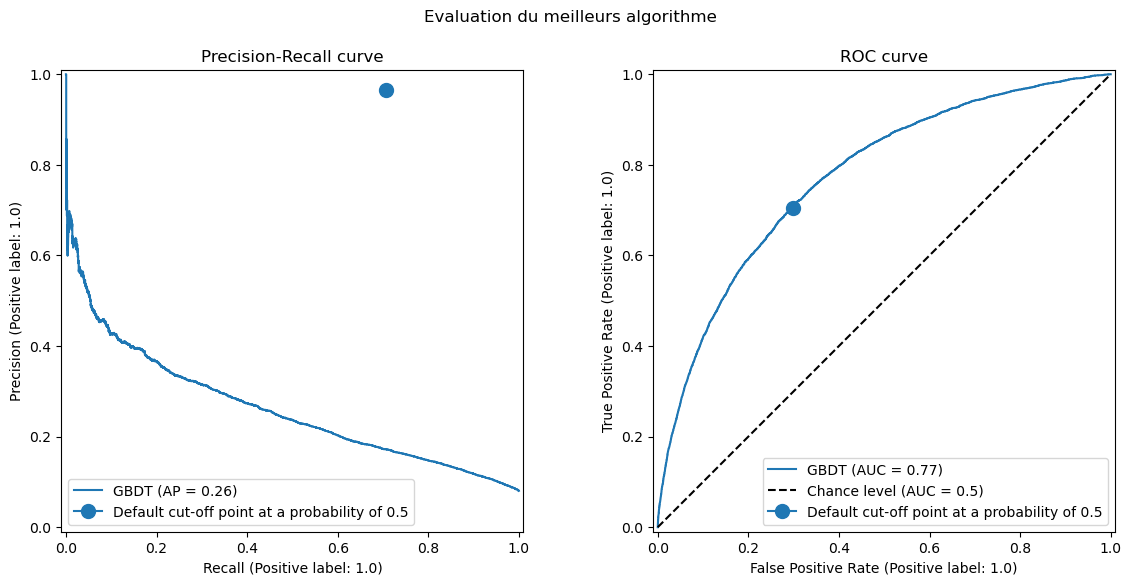

In [120]:
from sklearn.metrics import PrecisionRecallDisplay, RocCurveDisplay

fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(14, 6))

PrecisionRecallDisplay.from_estimator(
    model, X_test, y_test, ax=axs[0], name="GBDT"
)
axs[0].plot(
    scoring["recall"](model, X_test, y_test),
    scoring["precision"](model, X_test, y_test),
    marker="o",
    markersize=10,
    color="tab:blue",
    label="Default cut-off point at a probability of 0.5",
)
axs[0].set_title("Precision-Recall curve")
axs[0].legend()

RocCurveDisplay.from_estimator(
    model,
    X_test,
    y_test,
    ax=axs[1],
    name="GBDT",
    plot_chance_level=True,
)
axs[1].plot(
    scoring["fpr"](model, X_test, y_test),
    scoring["tpr"](model, X_test, y_test),
    marker="o",
    markersize=10,
    color="tab:blue",
    label="Default cut-off point at a probability of 0.5",
)
axs[1].set_title("ROC curve")
axs[1].legend()
_ = fig.suptitle("Evaluation du meilleurs algorithme")

plt.show()

Optimisation du seuil de décision

In [121]:
from sklearn.model_selection import TunedThresholdClassifierCV

In [122]:
with mlflow.start_run(run_name="HistGBC without ACP"):
    tuned_model = TunedThresholdClassifierCV(
        estimator=model,
        scoring=my_scorer,
        store_cv_results=True,  # necessary to inspect all results
        response_méthode="predict_proba",
    )
    tuned_model.fit(X_train, y_train)
    print(f"{tuned_model.best_threshold_=:0.2f}")

2026/02/13 13:34:18 WARNING mlflow.utils.autologging_utils: MLflow autologging encountered a warning: "D:\Users\SUZON\AppData\Local\anaconda3\envs\ml_flow_python_3_13_7\Lib\site-packages\mlflow\types\utils.py:452: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details."
2026/02/13 13:36:36 WARNING mlflow.utils.autologging_utils: MLflow autologging encountered a warning: "D:\Users\SUZON

tuned_model.best_threshold_=0.97


In [123]:
print(f"Business defined metric: {my_scorer(model, X_test, y_test)}")
print(f"Business defined metric: {my_scorer(tuned_model, X_test, y_test)}")

Business defined metric: -167866


2026/02/13 13:37:43 WARNING mlflow.utils.autologging_utils: MLflow autologging encountered a warning: "D:\Users\SUZON\AppData\Local\anaconda3\envs\ml_flow_python_3_13_7\Lib\site-packages\mlflow\types\utils.py:452: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details."


Business defined metric: -4940


In [124]:
def plot_roc_pr_curves(vanilla_model, tuned_model, *, title):
    fig, axs = plt.subplots(nrows=1, ncols=3, figsize=(21, 6))

    linestyles = ("dashed", "dotted")
    markerstyles = ("o", ">")
    colors = ("tab:blue", "tab:orange")
    names = ("Vanilla GBDT", "Tuned GBDT")
    for idx, (est, linestyle, marker, color, name) in enumerate(
        zip((vanilla_model, tuned_model), linestyles, markerstyles, colors, names)
    ):
        decision_threshold = getattr(est, "best_threshold_", 0.5)
        PrecisionRecallDisplay.from_estimator(
            est,
            X_test,
            y_test,
            pos_label=pos_label,
            linestyle=linestyle,
            color=color,
            ax=axs[0],
            name=name,
        )
        axs[0].plot(
            scoring["recall"](est, X_test, y_test),
            scoring["precision"](est, X_test, y_test),
            marker,
            markersize=10,
            color=color,
            label=f"Cut-off point at probability of {decision_threshold:.2f}",
        )
        RocCurveDisplay.from_estimator(
            est,
            X_test,
            y_test,
            pos_label=pos_label,
            curve_kwargs=dict(linestyle=linestyle, color=color),
            ax=axs[1],
            name=name,
            plot_chance_level=idx == 1,
        )
        axs[1].plot(
            scoring["fpr"](est, X_test, y_test),
            scoring["tpr"](est, X_test, y_test),
            marker,
            markersize=10,
            color=color,
            label=f"Cut-off point at probability of {decision_threshold:.2f}",
        )

    axs[0].set_title("Precision-Recall curve")
    axs[0].legend()
    axs[1].set_title("ROC curve")
    axs[1].legend()

    axs[2].plot(
        tuned_model.cv_results_["thresholds"],
        tuned_model.cv_results_["scores"],
        color="tab:orange",
    )
    axs[2].plot(
        tuned_model.best_threshold_,
        tuned_model.best_score_,
        "o",
        markersize=10,
        color="tab:orange",
        label="Optimal cut-off point for the business metric",
    )
    axs[2].legend()
    axs[2].set_xlabel("Decision threshold (probability)")
    axs[2].set_ylabel("Objective score (using cost-matrix)")
    axs[2].set_title("Objective score as a function of the decision threshold")
    fig.suptitle(title)

    plt.show()

2026/02/13 13:38:05 WARNING mlflow.utils.autologging_utils: MLflow autologging encountered a warning: "D:\Users\SUZON\AppData\Local\anaconda3\envs\ml_flow_python_3_13_7\Lib\site-packages\mlflow\types\utils.py:452: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details."
2026/02/13 13:38:20 WARNING mlflow.utils.autologging_utils: MLflow autologging encountered a warning: "D:\Users\SUZON

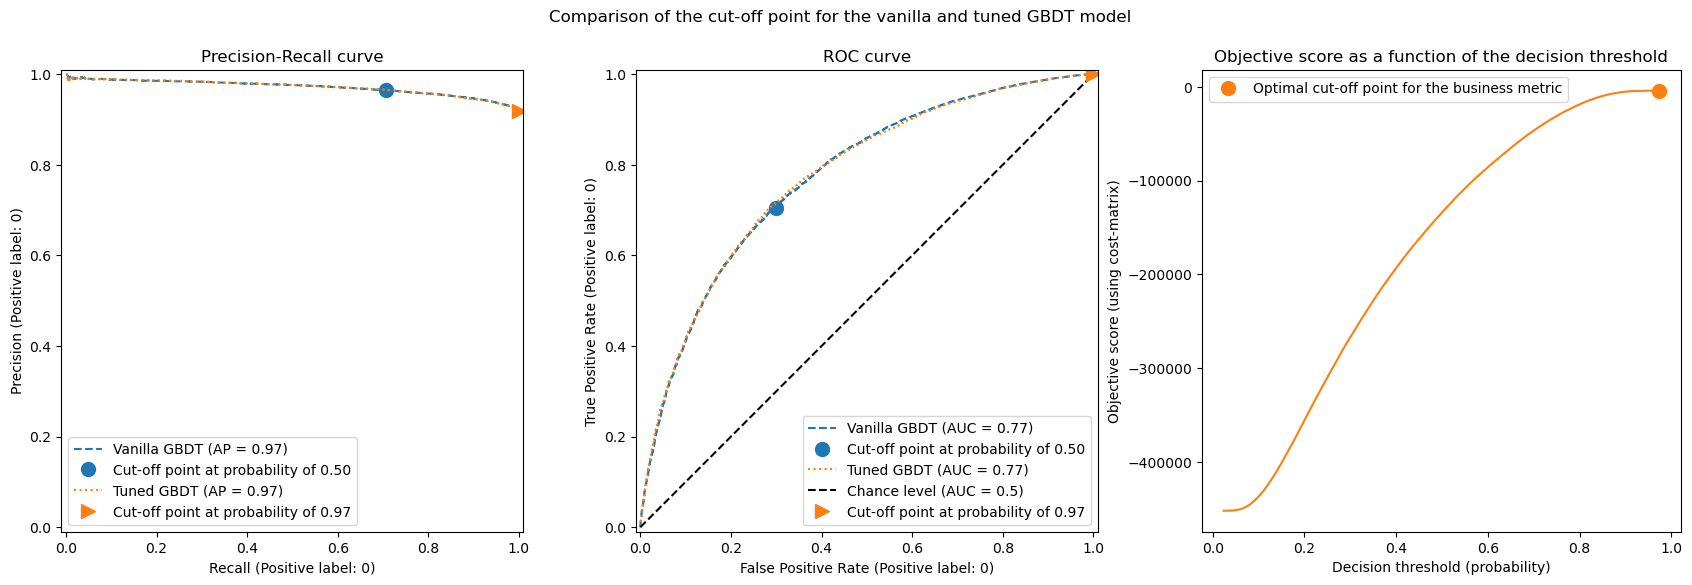

In [125]:
title = "Comparison of the cut-off point for the vanilla and tuned GBDT model"
plot_roc_pr_curves(model, tuned_model, title=title)

In [130]:
y_test_pred = model.predict(X_test)

In [132]:
y_test_pred

array([1., 0., 0., ..., 0., 0., 0.], shape=(61498,))

In [134]:
confusion_matrix(y_test, y_test_pred)

array([[39919, 16639],
       [ 1476,  3464]])

In [135]:
y_test_tuned_pred = tuned_model.predict(X_test)

2026/02/13 13:55:47 WARNING mlflow.utils.autologging_utils: MLflow autologging encountered a warning: "D:\Users\SUZON\AppData\Local\anaconda3\envs\ml_flow_python_3_13_7\Lib\site-packages\mlflow\types\utils.py:452: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details."


In [136]:
confusion_matrix(y_test, y_test_tuned_pred)

array([[56558,     0],
       [ 4940,     0]])

In [138]:
y_test.value_counts()

TARGET
0.0    56558
1.0     4940
Name: count, dtype: int64

In [139]:
y_train_tuned_pred = tuned_model.predict(X_train)
confusion_matrix(y_train, y_train_tuned_pred)

2026/02/13 14:11:43 WARNING mlflow.utils.autologging_utils: MLflow autologging encountered a warning: "D:\Users\SUZON\AppData\Local\anaconda3\envs\ml_flow_python_3_13_7\Lib\site-packages\mlflow\types\utils.py:452: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details."


array([[226107,      0],
       [ 19883,      0]])

In [140]:
y_train.value_counts()

TARGET
0.0    226107
1.0     19883
Name: count, dtype: int64

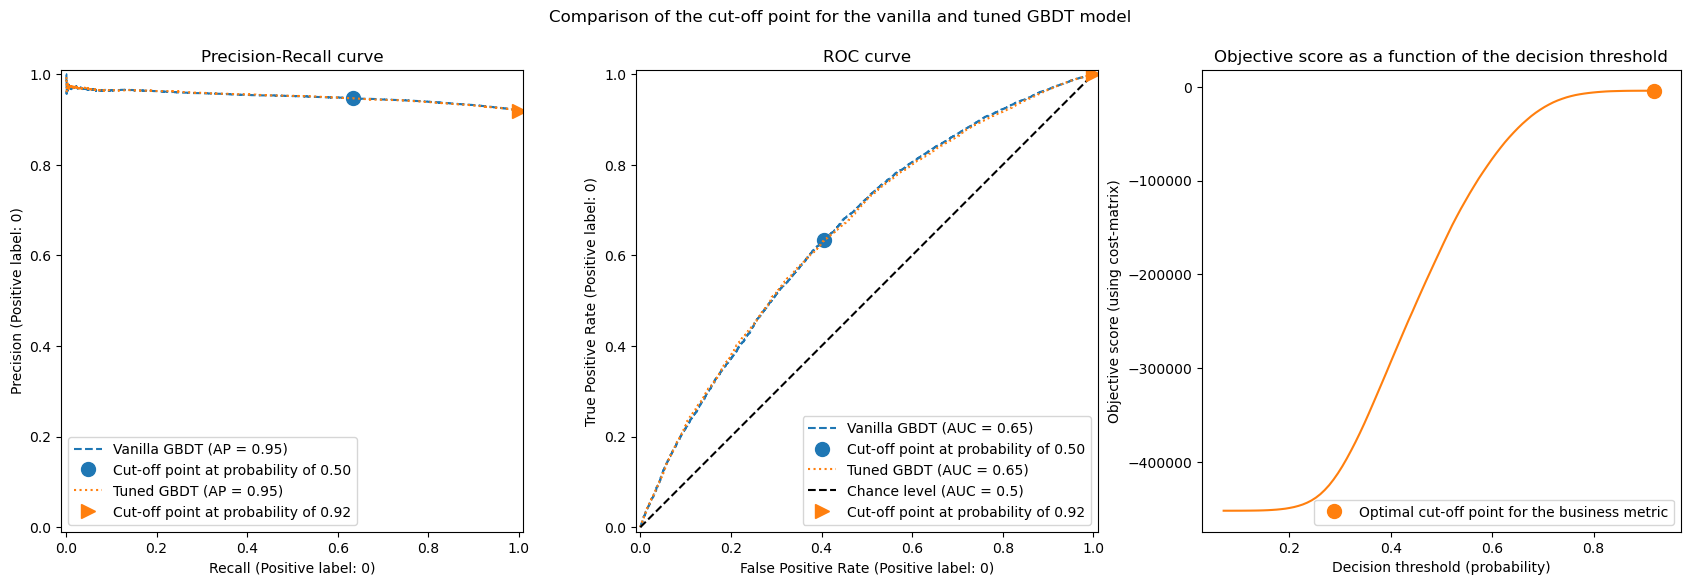

In [103]:
plt.show()

# Sauver le modèle lancer le dépoiment cloud

## Charger le model depuis la base de données de mlflow

In [142]:
import mlflow.sklearn
from mlflow import MlflowClient

client = MlflowClient()

In [144]:
# model version alias
model_name = "predict_client_payment"
model_version_alias = "best" # best version train ad date

# Get information about model
model_info = client.get_model_version_by_alias(model_name, model_version_alias)
model_tags = model_info.tags
print(model_tags)

2026/02/13 14:38:09 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/02/13 14:38:09 INFO mlflow.store.db.utils: Updating database tables
2026/02/13 14:38:09 INFO alembic.runtime.migration: Context impl SQLiteImpl.
2026/02/13 14:38:09 INFO alembic.runtime.migration: Will assume non-transactional DDL.


{'projet_7': 'model', 'validation_status': 'prending'}


In [145]:
# Get the model version using a model URI
model_uri = f"models:/{model_name}@{model_version_alias}"
model = mlflow.sklearn.load_model(model_uri)

In [146]:
print(model)

TunedThresholdClassifierCV(estimator=Pipeline(steps=[('imputer',
                                                      SimpleImputer(strategy='median')),
                                                     ('under_SMOTE',
                                                      RandomUnderSampler()),
                                                     ('over_SMOTE',
                                                      SMOTE(random_state=42)),
                                                     ('Scaler', MinMaxScaler()),
                                                     ('Classifier',
                                                      HistGradientBoostingClassifier(max_depth=10,
                                                                                     random_state=42))]),
                           scoring=make_scorer(my_metric, response_method='predict'),
                           store_cv_results=True)


## Sauver le modèle charger depuis la base de donnée

Signature d'un modèle

Afin de garantir que les données d'entrée d'un modèle sont conformes à ce qui est attendu, les modèles MLflow peuvent inclure des metadatas décrivant les entrées et sorties :
- Model Signature - description des entrées et sorties du modèle
- Model Input Example - exemple d'une entrée valide

La signature du modèle permet de renseigner le nom des colonnes et leurs types afin de vérifier si ils sont similaires lors de la prédiction.

[Documentation, exemple signature](https://mlflow.org/docs/latest/ml/model/signatures/)

In [147]:
from mlflow.models.signature import infer_signature

Faire charger les données utiliser pour l'entainement depuis le base de données mlflow pour creer la signature

In [149]:
signature = infer_signature(X_train, y_train)

D:\Users\SUZON\AppData\Local\anaconda3\envs\ml_flow_python_3_13_7\Lib\site-packages\mlflow\types\utils.py:452: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details.
  warnings.warn(


In [160]:
# Save path to deploy
save_path = r"C:\Users\SUZON\OneDrive - CNR\Documents\Jupyter\Openclassrooms\Projets Openclassrooms\Projet-7-Implementez-un-modele-de-scoring\data\modeles\best_SMOTE"

# requierement
requirements = {
                "name": "ml_flow_python_3_3_7",
                "channels": ["conda-forge"],
                "dependencies": [
                    "python=3.3.7",
                    {
                        "pip": [
                            "pandas==2.3.3",
                            "numpy==2.3.5",
                            "mlflow==3.7.0",
                            "imblearn==0.14.1",
                            "scikit-learn==1.8.0",
                            "cloudpickel==3.1.2",
                            "psutil==7.1.3",
                            "pyarrow==22.0.0",
                        ],
                    },
                ],
            }

# Allias du meilleurs modèle
mlflow.sklearn.save_model(model, save_path, signature=signature, pyfunc_predict_fn="predict", conda_env=requirements)

2026/02/13 15:32:59 WARNING mlflow.utils.requirements_utils: Detected one or more mismatches between the model's dependencies and the current Python environment:
 - cloudpickel (current: uninstalled, required: cloudpickel==3.1.2)
To fix the mismatches, call `mlflow.pyfunc.get_model_dependencies(model_uri)` to fetch the model's environment and install dependencies using the resulting environment file.
